# 03 · Backprop for the Output Layer

**Goal:** derive and implement the gradient of the loss with respect to the last layer's parameters, and *prove* it is right with a numerical gradient check.

Let $\delta^{[L]} = \partial \mathcal{L}/\partial Z^{[L]}$ ("the error signal" at the output). Then, for $Z^{[L]}=A^{[L-1]}W^{[L]}+b^{[L]}$:

$$\frac{\partial\mathcal L}{\partial W^{[L]}} = \left(A^{[L-1]}\right)^{\!\top}\delta^{[L]},\qquad
\frac{\partial\mathcal L}{\partial b^{[L]}} = \sum_{n}\delta^{[L]}_{n,:},\qquad
\frac{\partial\mathcal L}{\partial A^{[L-1]}} = \delta^{[L]}\left(W^{[L]}\right)^{\!\top}$$

For **softmax + cross-entropy** (mean over the batch) the error signal collapses to

$$\boxed{\delta^{[L]} = \tfrac{1}{N}\,(P - Y)}$$

where $P$ are predicted probabilities and $Y$ one-hot labels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(1)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(P, Y):
    return -np.sum(Y * np.log(P + 1e-12)) / Y.shape[0]

## 1. Why softmax + cross-entropy gives $P-Y$
For one sample: $\mathcal L=-\sum_k y_k\log p_k$ and the softmax Jacobian is $\partial p_i/\partial z_j = p_i(\delta_{ij}-p_j)$.
Chain rule: $\partial\mathcal L/\partial z_j = -\sum_k \frac{y_k}{p_k}\,p_k(\delta_{kj}-p_j) = -y_j + p_j\sum_k y_k = p_j - y_j$.  Let's confirm it with explicit Jacobians:

In [2]:
z = rng.normal(size=(1, 4))
p = softmax(z)[0]
y = np.array([0, 0, 1, 0.0])

dL_dp = -y / p                                   # gradient wrt probabilities
J = np.diag(p) - np.outer(p, p)                  # softmax Jacobian
dL_dz_chain = J @ dL_dp                          # chain rule through the Jacobian

print("chain rule :", np.round(dL_dz_chain, 6))
print("p - y      :", np.round(p - y, 6))
assert np.allclose(dL_dz_chain, p - y)

chain rule : [ 0.264066  0.425061 -0.739904  0.050778]
p - y      : [ 0.264066  0.425061 -0.739904  0.050778]


## 2. A complete output layer: forward, backward
We treat a single softmax layer as "the output layer" fed by some activations `A_prev` (pretend they came from hidden layers).

In [3]:
N, d, K = 8, 5, 3
A_prev = rng.normal(size=(N, d))
Y = np.eye(K)[rng.integers(0, K, N)]             # one-hot labels
W = rng.normal(0, 0.5, (d, K))
b = np.zeros(K)

# forward
Z = A_prev @ W + b
P = softmax(Z)
loss = cross_entropy(P, Y)

# backward
delta = (P - Y) / N                              # dL/dZ
dW = A_prev.T @ delta                            # (d,N)@(N,K) -> (d,K)
db = delta.sum(axis=0)                           # (K,)
dA_prev = delta @ W.T                            # (N,K)@(K,d) -> (N,d)  -> flows to previous layer

print("loss =", round(loss, 4))
print("shapes: dW", dW.shape, "| db", db.shape, "| dA_prev", dA_prev.shape)

loss = 1.5193
shapes: dW (5, 3) | db (3,) | dA_prev (8, 5)


## 3. Gradient checking – the most important debugging tool in deep learning
Central finite differences: $\;\dfrac{\partial\mathcal L}{\partial\theta_i}\approx\dfrac{\mathcal L(\theta_i+\varepsilon)-\mathcal L(\theta_i-\varepsilon)}{2\varepsilon}$

In [4]:
def numerical_grad(f, x, eps=1e-6):
    """Gradient of scalar f() wrt array x (modified in place and restored)."""
    g = np.zeros_like(x)
    it = np.nditer(x, flags=["multi_index"])
    for _ in it:
        idx = it.multi_index
        old = x[idx]
        x[idx] = old + eps; fp = f()
        x[idx] = old - eps; fm = f()
        x[idx] = old
        g[idx] = (fp - fm) / (2 * eps)
    return g

def rel_err(a, b):
    return np.linalg.norm(a - b) / (np.linalg.norm(a) + np.linalg.norm(b) + 1e-12)

f = lambda: cross_entropy(softmax(A_prev @ W + b), Y)
for name, analytic, arr in [("dW", dW, W), ("db", db, b), ("dA_prev", dA_prev, A_prev)]:
    num = numerical_grad(f, arr)
    print(f"{name:<8} relative error = {rel_err(analytic, num):.2e}")
# rule of thumb: < 1e-6 is great, > 1e-3 means a bug

dW       relative error = 1.96e-10
db       relative error = 7.97e-10
dA_prev  relative error = 6.00e-10


## 4. Other output layers
| Task | Output activation | Loss | $\delta^{[L]}$ |
|---|---|---|---|
| multi-class | softmax | cross-entropy | $(P-Y)/N$ |
| binary | sigmoid | binary cross-entropy | $(A-Y)/N$ |
| regression | identity | MSE ($\tfrac12$ squared error) | $(A-Y)/N$ |
| binary / sigmoid | sigmoid | MSE | $(A-Y)\,A(1-A)/N$  ← slow! |

Check the last two rows numerically:

In [5]:
def bce(A, Y):  return -np.mean(Y * np.log(A + 1e-12) + (1 - Y) * np.log(1 - A + 1e-12))
def mse(A, Y):  return 0.5 * np.sum((A - Y) ** 2) / Y.shape[0]

Xb = rng.normal(size=(10, 4)); Yb = rng.integers(0, 2, (10, 1)).astype(float)
Wb = rng.normal(size=(4, 1)); bb = np.zeros(1)

Ab = sigmoid(Xb @ Wb + bb)
d_bce = (Ab - Yb) / 10                      # sigmoid + BCE
d_mse = (Ab - Yb) * Ab * (1 - Ab) / 10      # sigmoid + MSE

f_bce = lambda: bce(sigmoid(Xb @ Wb + bb), Yb)
f_mse = lambda: mse(sigmoid(Xb @ Wb + bb), Yb)
print("BCE dW error:", f"{rel_err(Xb.T @ d_bce, numerical_grad(f_bce, Wb)):.2e}")
print("MSE dW error:", f"{rel_err(Xb.T @ d_mse, numerical_grad(f_mse, Wb)):.2e}")

BCE dW error: 1.20e-10
MSE dW error: 3.91e-10


## 5. Why cross-entropy trains faster than MSE with sigmoid
For a positive example ($y=1$) as the neuron becomes *confidently wrong* ($z\to-\infty$), MSE's gradient $\propto (a-1)\,a(1-a)$ vanishes because the sigmoid saturates, while cross-entropy keeps a gradient of $a-1\to-1$.

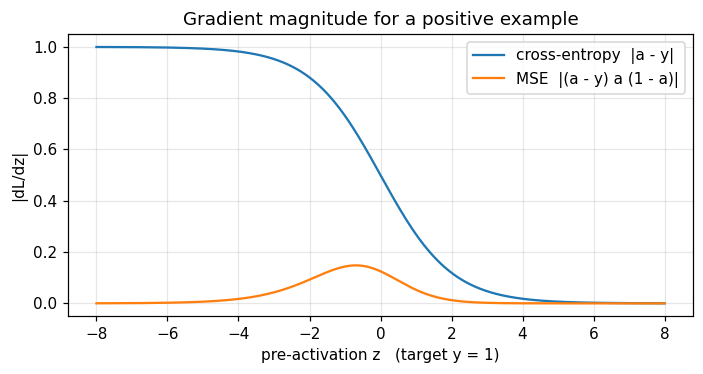

In [6]:
zs = np.linspace(-8, 8, 400)
a = sigmoid(zs)
g_mse = np.abs((a - 1) * a * (1 - a))
g_ce  = np.abs(a - 1)

plt.figure(figsize=(6.5, 3.5))
plt.plot(zs, g_ce, label="cross-entropy  |a - y|")
plt.plot(zs, g_mse, label="MSE  |(a - y) a (1 - a)|")
plt.xlabel("pre-activation z   (target y = 1)"); plt.ylabel("|dL/dz|")
plt.title("Gradient magnitude for a positive example")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### Try it yourself
1. Add L2 regularisation $\frac{\lambda}{2}\lVert W\rVert^2$ to the loss. What is the new `dW`? Verify with `numerical_grad`.
2. Implement softmax cross-entropy with *label smoothing* and derive its $\delta$.
3. Break the gradient on purpose (e.g. forget the `/ N`) and watch the gradient check fail.